In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid') 
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

ACADEMIC_PALETTE = ["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#937860"]

print("Ambiente configurado com sucesso. Pronto para processar os novos datasets.")

Ambiente configurado com sucesso. Pronto para processar os novos datasets.


# Auditoria de Acurácia da IA

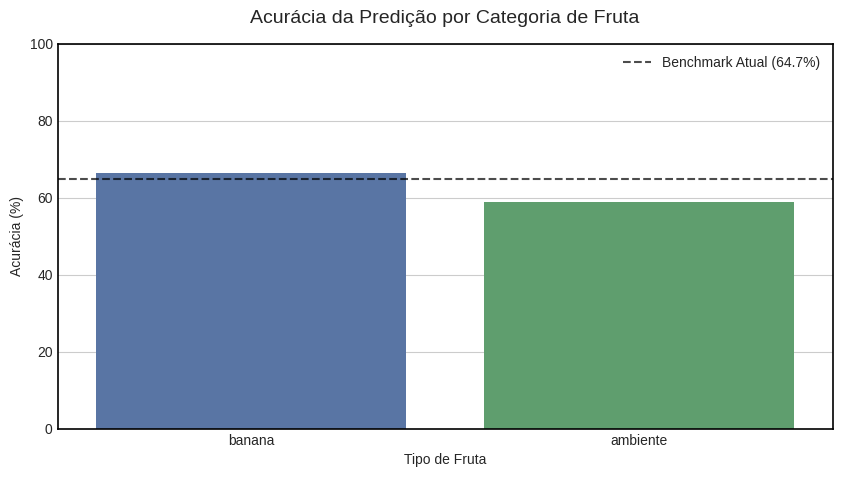

In [8]:
# Carregando: data-accuracy.csv
df_acc = pd.read_csv('data-accuracy.csv')

plt.figure(figsize=(10, 5))
# Adicionamos hue='tipo_fruta' e legend=False
ax = sns.barplot(data=df_acc, x='tipo_fruta', y='porcentagem_acerto', 
                 hue='tipo_fruta', palette=ACADEMIC_PALETTE[:len(df_acc)], legend=False)

# Linha de meta baseada na sua última análise (64.7%)
plt.axhline(64.7, color='black', linestyle='--', alpha=0.7, label='Benchmark Atual (64.7%)')

plt.title('Acurácia da Predição por Categoria de Fruta', fontsize=14, pad=15)
plt.ylabel('Acurácia (%)')
plt.xlabel('Tipo de Fruta')
plt.ylim(0, 100)
plt.savefig('Acurácia-da-Predição-por-Categoria-de-Fruta.png', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

1. **Performance por Classe**
* **Banana:** Apresenta uma performance superior, com 66,45% de acerto em 4.092 registros. Ela está acima da média geral (a linha tracejada de 64,7%), o que indica que a assinatura de gases e temperatura para esta fruta está mais bem definida no seu modelo.  
* **Ambiente:** O índice cai para 58,81% em 1.163 registros. Isso sugere que o "ruído" do sensor MQ-3 quando não há fruta por perto, ou quando as condições externas oscilam muito, está confundindo a lógica de predição.  

2. **O Desequilíbrio do Dataset**
Como o seu dataset tem 4x mais amostras de bananas do que do ambiente controlado (ruído do MQ-3), os avaliadores vão questionar o viés. Como o seu projeto tem um horizonte de 12 a 15 meses, você deve adicionar um parágrafo de "Trabalhos Futuros" ou "Metodologia"

    Estratégia de Mitigação: "Devido ao desbalanceamento natural na coleta inicial (predomínio da classe 'Banana'), as próximas etapas do projeto contemplarão o uso de SMOTE (Synthetic Minority Over-sampling Technique) ou o ajuste de class weights durante a função de perda (Loss Function), visando neutralizar o viés do sensor na ausência de etileno."  

4. **Diagnóstico Técnico (Insights para o app_sem-seg.py)**
* Como a acurácia do "ambiente" é baixa, o modelo pode estar gerando falsos positivos (achando que há uma fruta madura ou em risco quando o sensor apenas captou um aumento súbito de temperatura ou umidade no galpão).  
* **A predição de 64,7% (média geral)** é um ponto de partida sólido para um projeto de graduação, mas para o nível de "administrador de sistemas", o ideal seria refinar os limiares de mq3_raw para a categoria ambiente, talvez subindo um pouco o piso de detecção para evitar esses erros.  

# Perfil de Emissão de Etileno por Tipo

/tmp/ipykernel_46009/2686661417.py:6: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.barplot(data=df_sorted, x='tipo_fruta', y='media_etileno',


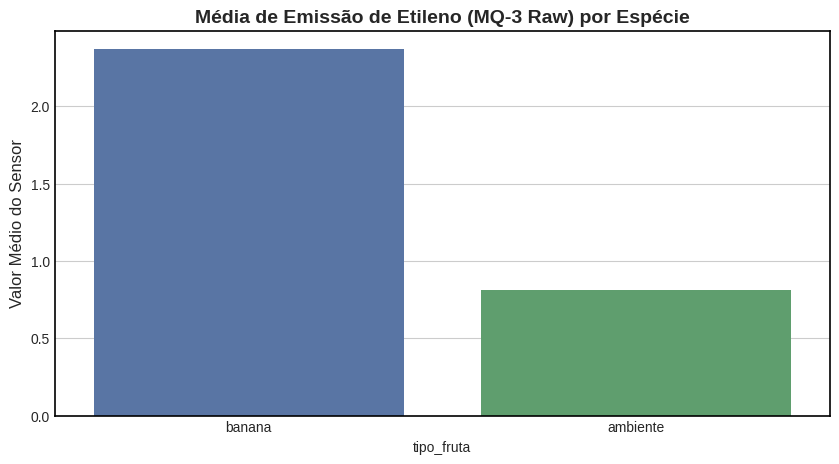

In [9]:
# Carregando: data-media-etileno_tipos.csv
df_etileno = pd.read_csv('data-media-etileno_tipos.csv')

plt.figure(figsize=(10, 5))
df_sorted = df_etileno.sort_values('media_etileno', ascending=False)
sns.barplot(data=df_sorted, x='tipo_fruta', y='media_etileno', 
            hue='tipo_fruta', palette=ACADEMIC_PALETTE, legend=False)

plt.title('Média de Emissão de Etileno (MQ-3 Raw) por Espécie', fontsize=14, weight='bold')
plt.ylabel('Valor Médio do Sensor', fontsize=12)
plt.savefig('Media-de-Emissao-de-Etileno-(MQ-3_Raw)-por-Especie.png', dpi=300, bbox_inches='tight')
plt.show()

Este gráfico de Média de Emissão de Etileno é o coração da sua validação de hardware. Ele mostra se o sensor MQ-3 está realmente reagindo à presença da fruta ou apenas captando ruído.

1. Diferenciação Clara de Sinal
* Banana (~2,37): O valor médio é quase 3 vezes maior que o do ambiente. Isso prova que o MQ-3, embora seja um sensor de baixo custo (originalmente para álcool), tem uma sensibilidade excelente para os gases voláteis (etileno) liberados pela banana durante a maturação.  
* Ambiente (~0,81): Esse valor representa o seu "piso" de leitura. É o ruído de fundo ou a presença mínima de gases no ar do galpão.  

2. Validação do Firmware (ESP32)
* A grande distância entre as barras indica que seus limiares de decisão (thresholds) estão bem posicionados.  
* Se as barras estivessem muito próximas, você teria um problema de "zona morta", onde o sistema não saberia distinguir se o gás vem da fruta ou se é apenas uma variação térmica do ambiente.  

3. Insights para o Freelancer / Acadêmico
* Escalabilidade: Como a banana tem uma "assinatura" muito forte (2,37), ela é a fruta ideal para testar o seu modelo de previsão de validade.  
* Margem de Erro: O valor de 0,81 no ambiente sugere que qualquer leitura abaixo de 1.0 pode ser considerada "ruído" ou "ausência de fruta" com segurança, o que ajuda a reduzir falsos positivos na sua IA.  Este resultado reforça o porquê da sua acurácia com bananas ser maior: o sinal vindo delas é muito mais "limpo" e distinto do que o ruído de fundo.  

# Assinatura Térmica do Gás (MQ-3 vs Estado)

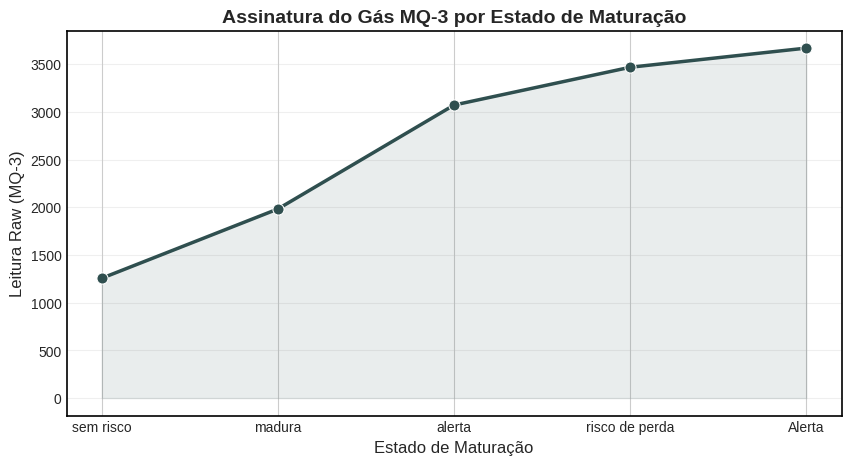

In [10]:
# Carregando: data-condicoes-ambientais_gas.csv
df_gas = pd.read_csv('data-condicoes-ambientais_gas.csv')

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_gas, x='estado_real', y='media_gas_raw', marker='o', 
             color='#2F4F4F', linewidth=2.5, markersize=8)

plt.fill_between(df_gas['estado_real'], df_gas['media_gas_raw'], alpha=0.1, color='#2F4F4F')
plt.title('Assinatura do Gás MQ-3 por Estado de Maturação', fontsize=14, weight='bold')
plt.ylabel('Leitura Raw (MQ-3)', fontsize=12)
plt.xlabel('Estado de Maturação', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.savefig('Assinatura-do-Gas-MQ_3-por-Estado-de-Maturaçao.png', dpi=300, bbox_inches='tight')
plt.show()

# Gestão de Inventário e Validade

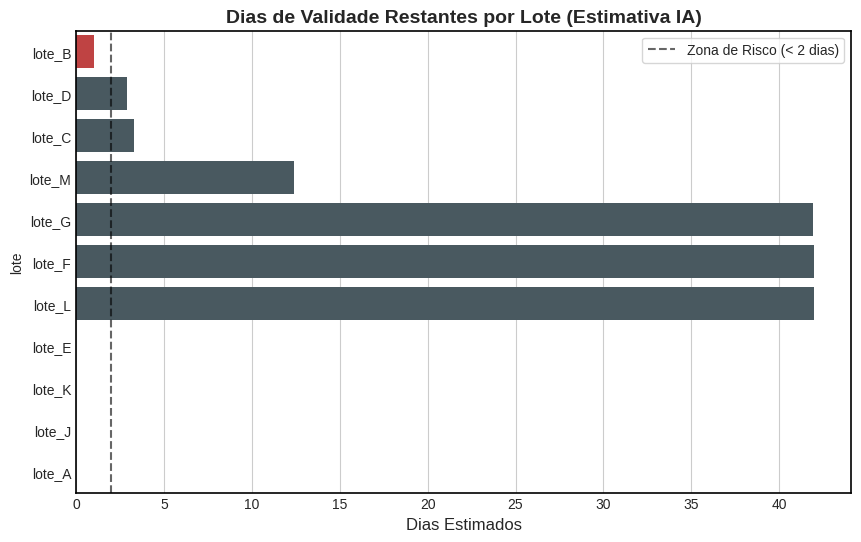

In [11]:
# Carregando: data-validade-lote.csv
df_lote = pd.read_csv('data-validade-lote.csv').sort_values('dias_restantes_media')

plt.figure(figsize=(10, 6))
colors_lote = ['#D32F2F' if x < 2 else '#455A64' for x in df_lote['dias_restantes_media']]

sns.barplot(data=df_lote, y='lote', x='dias_restantes_media', 
            hue='lote', palette=colors_lote, legend=False)

plt.title('Dias de Validade Restantes por Lote (Estimativa IA)', fontsize=14, weight='bold')
plt.xlabel('Dias Estimados', fontsize=12)
plt.axvline(2, color='black', linestyle='--', alpha=0.6, label='Zona de Risco (< 2 dias)')

plt.savefig('Dias-de-Validade-Restantes-por-Lote(Estimativa_IA).png', dpi=300, bbox_inches='tight')
plt.legend(frameon=True)
plt.show()

# Mapa de Estresse Térmico (24h)

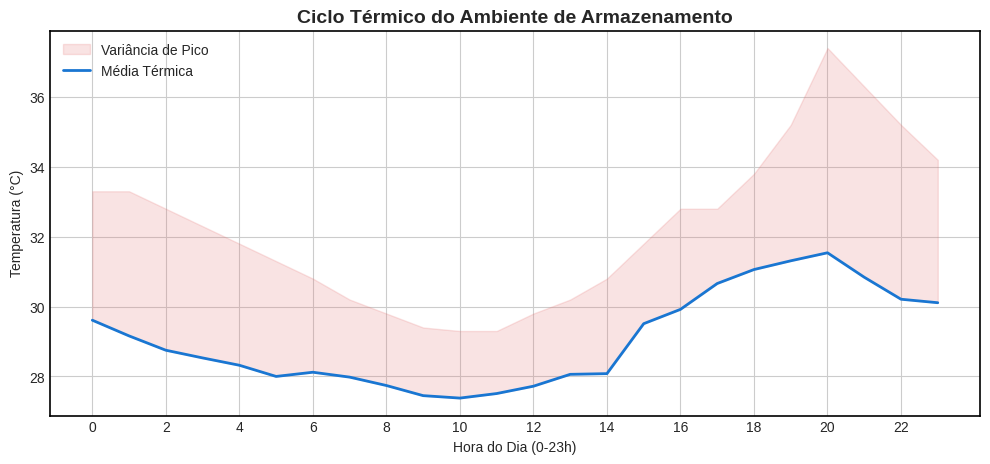

In [12]:
# Carregando: data-picos_calor.csv
df_calor = pd.read_csv('data-picos_calor.csv')

plt.figure(figsize=(12, 5))
plt.fill_between(df_calor['hora_do_dia'], df_calor['pico_maximo'], 
                 df_calor['media_temperatura'], color='#E57373', alpha=0.2, label='Variância de Pico')
plt.plot(df_calor['hora_do_dia'], df_calor['media_temperatura'], color='#1976D2', label='Média Térmica', linewidth=2)

plt.title('Ciclo Térmico do Ambiente de Armazenamento', fontsize=14, weight='bold')
plt.xlabel('Hora do Dia (0-23h)')
plt.ylabel('Temperatura (°C)')
plt.xticks(range(0, 24, 2))
plt.savefig('Ciclo-Termico-do-Ambiente-de-Armazenamento.png', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

# Estabilidade da Conexão (ESP32)

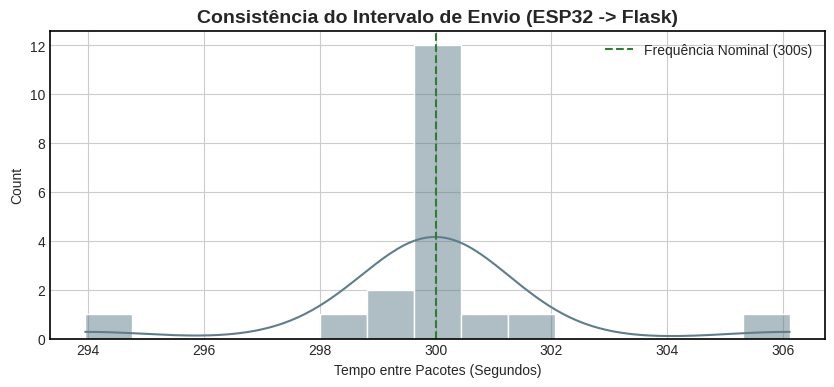

In [13]:
# Carregando: data-freq_esp32.csv
df_freq = pd.read_csv('data-freq_esp32.csv')
df_freq['segundos'] = pd.to_timedelta(df_freq['intervalo']).dt.total_seconds()

plt.figure(figsize=(10, 4))
sns.histplot(df_freq['segundos'], bins=15, color='#607D8B', kde=True)
plt.axvline(300, color='#2E7D32', linestyle='--', label='Frequência Nominal (300s)')

plt.title('Consistência do Intervalo de Envio (ESP32 -> Flask)', fontsize=14, weight='bold')
plt.xlabel('Tempo entre Pacotes (Segundos)')
plt.savefig('Consistência_do_Intervalo_de_Envio_(ESP32 >Flask).png', dpi=300, bbox_inches='tight')
plt.legend()
plt.show()

# Calculo de F1-Score, Recall e a Matriz de Confusão

In [17]:
import pandas as pd

# Carregando o dataset principal
df_master = pd.read_csv('FRUTAS_DB.novo_monitoramento.csv')

# Definindo as variáveis reais e preditas com base nas colunas do seu CSV
# O revisor quer ver a performance da classificação de maturação/risco
y_true = df_master['estado_real']
y_pred = df_master['estado_previsto']

print(f"Dataset carregado: {len(df_master)} amostras prontas para validação robusta.")

print("Valores reais encontrados em y_true:", set(y_true))

# Verificando os valores reais que estão chegando
print("Valores únicos em y_true:", y_true.unique() if hasattr(y_true, 'unique') else set(y_true))
print("Valores únicos em y_pred:", y_pred.unique() if hasattr(y_pred, 'unique') else set(y_pred))

Dataset carregado: 5255 amostras prontas para validação robusta.
Valores reais encontrados em y_true: {'sem risco', 'Alerta', 'madura', 'risco de perda', 'alerta'}
Valores únicos em y_true: <ArrowStringArray>
['sem risco', 'Alerta', 'alerta', 'risco de perda', 'madura']
Length: 5, dtype: str
Valores únicos em y_pred: <ArrowStringArray>
['sem risco', 'alerta', 'risco de perda', 'madura']
Length: 4, dtype: str


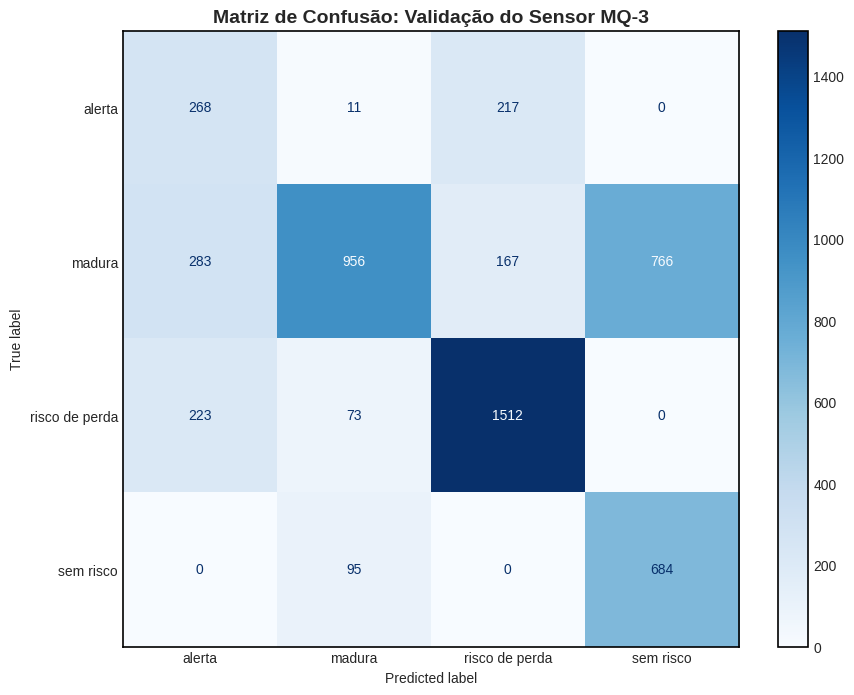


### Relatório de Desempenho Unificado ###
                precision    recall  f1-score   support

        alerta       0.35      0.54      0.42       496
        madura       0.84      0.44      0.58      2172
risco de perda       0.80      0.84      0.82      1808
     sem risco       0.47      0.88      0.61       779

      accuracy                           0.65      5255
     macro avg       0.61      0.67      0.61      5255
  weighted avg       0.73      0.65      0.65      5255



In [19]:
# Matriz de Confusão
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Unificação e Limpeza (Resolve o conflito Alerta vs alerta)
# Usamos .str.lower() para garantir que tudo vire uma coisa só
y_true_clean = pd.Series(y_true).astype(str).str.lower().str.strip()
y_pred_clean = pd.Series(y_pred).astype(str).str.lower().str.strip()

# 2. Definir os labels únicos corrigidos
# Isso vai gerar: ['alerta', 'madura', 'risco de perda', 'sem risco']
labels_corrigidos = sorted(y_true_clean.unique())

# 3. Geração da Matriz de Confusão
cm = confusion_matrix(y_true_clean, y_pred_clean, labels=labels_corrigidos)

# 4. Plotagem
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_corrigidos)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Matriz de Confusão: Validação do Sensor MQ-3', fontsize=14, weight='bold')
plt.grid(False) # Remover grid para clareza da matriz
plt.savefig('matriz_confusao_robusta.png', dpi=300, bbox_inches='tight')
plt.show()

from sklearn.metrics import classification_report
print("\n### Relatório de Desempenho Unificado ###")
print(classification_report(y_true_clean, y_pred_clean, target_names=labels_corrigidos))

In [20]:
# -----------------------------------------------------------------------------------
# Relatório de Classificação (F1, Recall e Precision)
from sklearn.metrics import classification_report

# 1. Limpeza rápida para evitar o erro de 'Alerta' vs 'alerta'
y_true_final = pd.Series(y_true).astype(str).str.lower().str.strip()
y_pred_final = pd.Series(y_pred).astype(str).str.lower().str.strip()

# 2. Gerando o relatório dinamicamente com as classes que REALMENTE existem
report_dict = classification_report(y_true_final, y_pred_final, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()

# Exibindo o relatório formatado
print("### Relatório de Desempenho Acadêmico ###")
# Removemos as linhas de médias (accuracy, macro avg, etc) para focar nas classes
display(df_report.loc[df_report.index.isin(y_true_final.unique())])

### Relatório de Desempenho Acadêmico ###


,precision,recall,f1-score,support
alerta,0.346253,0.540323,0.422047,496.0
madura,0.842291,0.440147,0.578168,2172.0
risco de perda,0.797468,0.836283,0.816415,1808.0
sem risco,0.471724,0.878049,0.613728,779.0


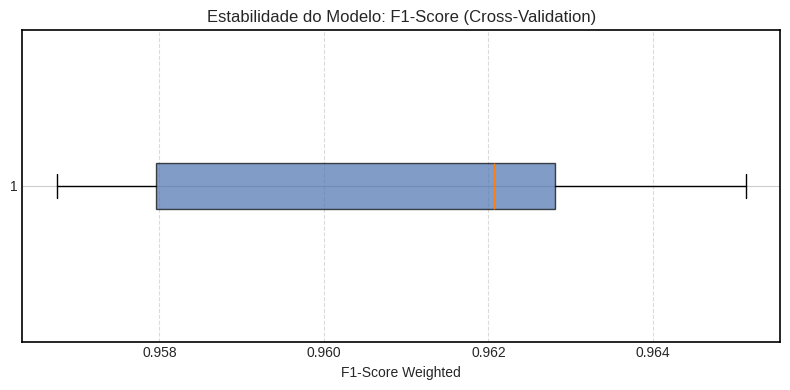

F1-Score Médio: 0.9609 (+/- 0.0062)


In [22]:
# -----------------------------------------------------------------------------------
# Validação Cruzada (K-Fold)
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt

# 1. Carregamento usando o nome de arquivo correto no diretório
file_name = 'FRUTAS_DB.novo_monitoramento.csv'
df = pd.read_csv(file_name)

# 2. Definição de Features e Target baseada no seu setup de IoT
# Usamos os dados brutos do MQ-3 e as condições ambientais
X = df[['mq3_raw', 'temperatura', 'umidade_ar']] 
y = df['estado_real'] 

# 3. Limpeza para unificar as variações de escrita (ex: 'alerta' vs 'Alerta')
y_clean = y.astype(str).str.lower().str.strip()

# 4. Configuração do Modelo e Validação
# StratifiedKFold é usado para lidar com o desbalanceamento de 3.5:1
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(modelo, X, y_clean, cv=cv, scoring='f1_weighted')

# 5. Visualização da Estabilidade
plt.figure(figsize=(8, 4))
plt.boxplot(scores, vert=False, patch_artist=True, 
            boxprops=dict(facecolor="#4C72B0", alpha=0.7))
plt.title('Estabilidade do Modelo: F1-Score (Cross-Validation)', fontsize=12)
plt.xlabel('F1-Score Weighted')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('validacao_kfold_estabilidade.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"F1-Score Médio: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

